✅ Loaded 1151 clean reviews from Regex preprocessing.

Loading AI Model...


Device set to use cpu



Running Analysis on 1151 reviews (Batch Size: 100)...


Processing Batches: 100%|██████████| 12/12 [00:59<00:00,  5.00s/it]


✅ Analysis Complete! Saved to: ../Data/processed/reviews_with_sentiment.csv

Sample Results:


,review,sentiment_label,sentiment_score
0,very good,POSITIVE,0.999852
1,most of the time is not working properly,NEGATIVE,0.999764
2,good service,POSITIVE,0.999850
3,not use for me,NEGATIVE,0.995374
4,It keeps notifying me to disable developer opt...,NEGATIVE,0.996833


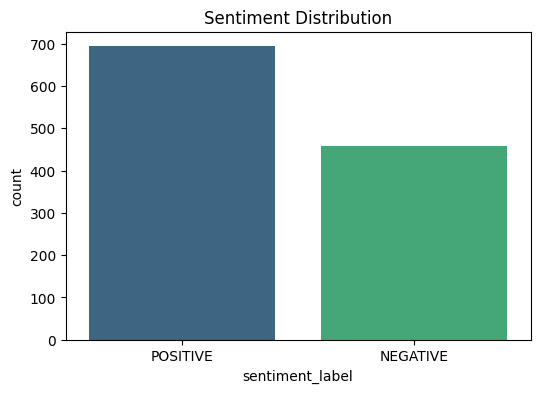

In [1]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
from transformers import pipeline
from tqdm import tqdm
import os
import math

# --- CONFIGURATION ---
# We use the REGEX file because it kept 96% of the data (1151 rows)
input_file = '../Data/processed/reviews_processed_regex.csv'
output_file = '../Data/processed/reviews_with_sentiment.csv'

# 1. Load the Clean Data
if os.path.exists(input_file):
    df = pd.read_csv(input_file)
    print(f"✅ Loaded {len(df)} clean reviews from Regex preprocessing.")
else:
    print(f"❌ Error: File not found at {input_file}")
    # Stop execution if file missing
    raise FileNotFoundError("Input file missing")

# 2. Load the AI Model
# We use 'distilbert-base-uncased-finetuned-sst-2-english' as requested in the challenge
print("\nLoading AI Model...")
sentiment_pipeline = pipeline("sentiment-analysis", model="distilbert-base-uncased-finetuned-sst-2-english")

# 3. CHUNK PROCESSING
# We process 100 reviews at a time. This is faster and safer.
CHUNK_SIZE = 100
total_reviews = len(df)
results = []

print(f"\nRunning Analysis on {total_reviews} reviews (Batch Size: {CHUNK_SIZE})...")

# Loop through the data in steps of 100
for start_idx in tqdm(range(0, total_reviews, CHUNK_SIZE), desc="Processing Batches"):
    # Define the batch slice
    end_idx = min(start_idx + CHUNK_SIZE, total_reviews)

    # Get the list of text for this batch
    # We ensure they are strings to avoid errors
    batch_reviews = df['review'].iloc[start_idx:end_idx].astype(str).tolist()

    try:
        # Pass the ENTIRE batch to the model at once (Much Faster!)
        batch_results = sentiment_pipeline(batch_reviews, truncation=True, max_length=512)
        results.extend(batch_results)

    except Exception as e:
        print(f"⚠️ Error in batch {start_idx}-{end_idx}: {e}")
        # If a batch fails, fill with Neutral so we don't break the dataframe alignment
        # This keeps the rest of your data safe
        results.extend([{'label': 'NEUTRAL', 'score': 0.0}] * len(batch_reviews))

# 4. Attach Results to DataFrame
# Safety check: ensure results match dataframe length
if len(results) == len(df):
    df['sentiment_label'] = [res['label'] for res in results]
    df['sentiment_score'] = [res['score'] for res in results]

    # 5. Save the Enriched Data
    os.makedirs(os.path.dirname(output_file), exist_ok=True)
    df.to_csv(output_file, index=False)
    print(f"\n✅ Analysis Complete! Saved to: {output_file}")

    # 6. Preview
    print("\nSample Results:")
    display(df[['review', 'sentiment_label', 'sentiment_score']].head(5))

    # 7. Visualization
    plt.figure(figsize=(6, 4))
    sns.countplot(x='sentiment_label', data=df,hue='sentiment_label',
    palette='viridis',
    legend=False)
    plt.title("Sentiment Distribution")
    plt.show()

else:
    print(f"❌ Error: Result count ({len(results)}) does not match Row count ({len(df)})")

[nltk_data] Downloading package stopwords to /Users/admin/nltk_data...
[nltk_data]   Package stopwords is already up-to-date!



--- KEYWORD ANALYSIS ---

🚩 Top 10 Pain Points (Negative Reviews):
  - working: 38
  - even: 38
  - please: 38
  - work: 36
  - worst: 35
  - update: 33
  - money: 31
  - time: 29
  - fix: 29
  - like: 28

✅ Top 10 Success Drivers (Positive Reviews):
  - best: 95
  - dashen: 34
  - great: 33
  - super: 29
  - easy: 27
  - one: 25
  - excellent: 25
  - wow: 25
  - fast: 23
  - like: 21


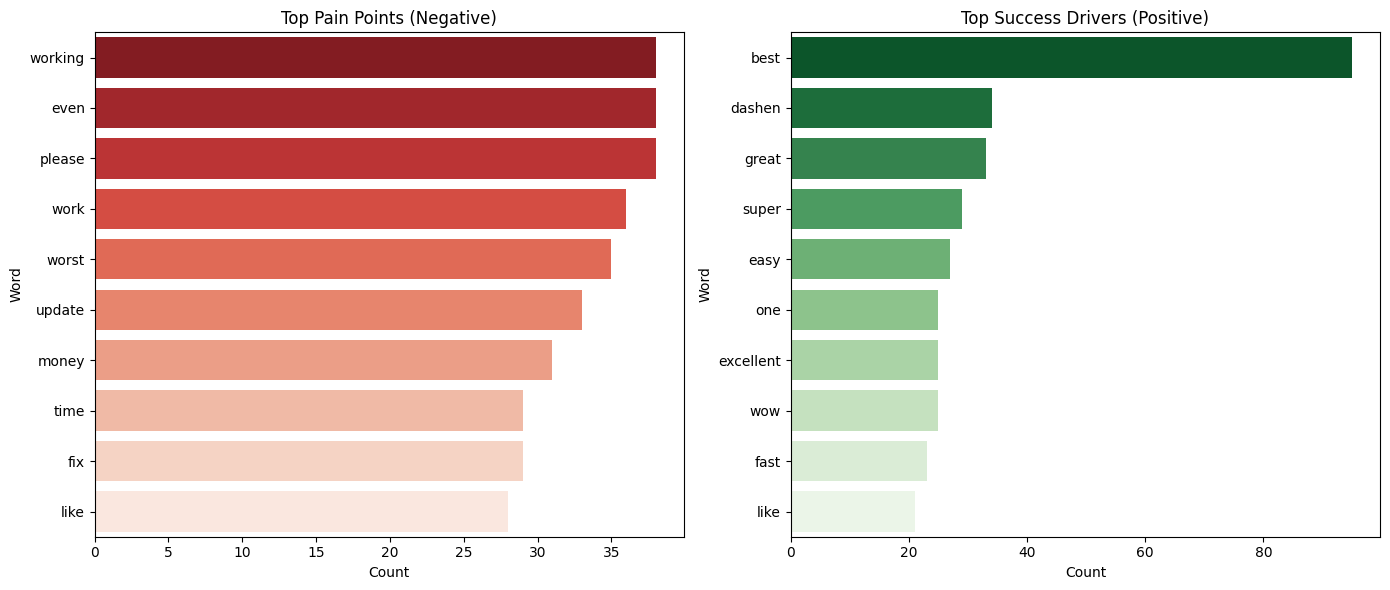

In [3]:
# --- THEMATIC ANALYSIS (Keyword Extraction) ---
from collections import Counter
import re
from nltk.corpus import stopwords
import nltk
import ssl  # <--- NEW IMPORT

# --- FIX 1: Bypass SSL Certificate Error (Mac specific issue) ---
try:
    _create_unverified_https_context = ssl._create_unverified_context
except AttributeError:
    pass
else:
    ssl._create_default_https_context = _create_unverified_https_context
# ----------------------------------------------------------------

# 1. Download Stopwords
print("Downloading NLTK stopwords...")
nltk.download('stopwords')
stop_words = set(stopwords.words('english'))

# Add custom banking stopwords
custom_stops = {'app', 'bank', 'banking', 'ethiopia', 'mobile', 'application', 'service', 'use', 'good', 'nice', 'cant', 'doesnt'}
stop_words.update(custom_stops)

def extract_keywords(text_series, top_n=10):
    """Extracts most frequent words from text series."""
    # Convert to string, lower case
    all_text = " ".join(text_series.astype(str).tolist()).lower()
    # Remove non-letters
    all_text = re.sub(r'[^a-z\s]', '', all_text)
    # Tokenize
    words = all_text.split()
    # Filter stopwords and short words
    filtered_words = [w for w in words if w not in stop_words and len(w) > 2]
    return Counter(filtered_words).most_common(top_n)

# 2. Extract Keywords
print("\n--- KEYWORD ANALYSIS ---")

# A. PAIN POINTS (Negative Reviews)
neg_reviews = df[df['sentiment_label'] == 'NEGATIVE']['review']
pain_points = extract_keywords(neg_reviews, top_n=10)

print("\n🚩 Top 10 Pain Points (Negative Reviews):")
for word, count in pain_points:
    print(f"  - {word}: {count}")

# B. DRIVERS (Positive Reviews)
pos_reviews = df[df['sentiment_label'] == 'POSITIVE']['review']
drivers = extract_keywords(pos_reviews, top_n=10)

print("\n✅ Top 10 Success Drivers (Positive Reviews):")
for word, count in drivers:
    print(f"  - {word}: {count}")

# 3. Visualize Keywords
fig, axes = plt.subplots(1, 2, figsize=(14, 6))

# Negative Plot (Fixed Warnings)
neg_df = pd.DataFrame(pain_points, columns=['Word', 'Count'])
sns.barplot(
    data=neg_df,
    x='Count',
    y='Word',
    hue='Word',       # <--- FIX for Warning
    ax=axes[0],
    palette='Reds_r',
    legend=False      # <--- FIX for Warning
)
axes[0].set_title('Top Pain Points (Negative)')

# Positive Plot (Fixed Warnings)
pos_df = pd.DataFrame(drivers, columns=['Word', 'Count'])
sns.barplot(
    data=pos_df,
    x='Count',
    y='Word',
    hue='Word',       # <--- FIX for Warning
    ax=axes[1],
    palette='Greens_r',
    legend=False      # <--- FIX for Warning
)
axes[1].set_title('Top Success Drivers (Positive)')

plt.tight_layout()
plt.show()